# Synthetic Control Method

This notebook presents the **in store navigation** case and the core analysis workflow.

# Data

In [1]:
import pandas as pd
from causalis.scenarios.synthetic_control.dgp import generate_scm_poisson_26


df = generate_scm_poisson_26(
    return_panel_data=False,
    include_oracles=True
)

# Treated post-period rows are exactly treated_time == 1
post_treated = df[df["treated_time"] == 1].copy()
atte_true = post_treated["tau_realized_true"].mean()
relative_lift_realized = (post_treated["tau_realized_true"] / post_treated["y_cf"].replace(0, pd.NA)).dropna().mean()

print(f"Ground-truth ATTE is {atte_true:.6f}")



Ground-truth ATTE is 2.750000


In [2]:
df.head()

,unit_id,calendar_time,treated_time,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true
0,donor_1,2000-01,0,4.0,4.0,0.0,6.150671,6.150671,0.0
1,donor_1,2000-02,0,9.0,9.0,0.0,5.599403,5.599403,0.0
2,donor_1,2000-03,0,4.0,4.0,0.0,4.978119,4.978119,0.0
3,donor_1,2000-04,0,6.0,6.0,0.0,5.777247,5.777247,0.0
4,donor_1,2000-05,0,8.0,8.0,0.0,5.685711,5.685711,0.0


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)

# EDA

In [4]:
paneldata

PanelDataSCM(df=(3885, 4), y='y', unit_col='unit_id', time_col='calendar_time', treated_time='treated_time', time_freq='M', treated_unit='treated', treatment_start=Period('2015-02', 'M'), last_post_period=Period('2015-05', 'M'), n_pre_periods=181, n_post_periods=4, donor_units=['donor_1', 'donor_10', 'donor_11', 'donor_12', 'donor_13', 'donor_14', 'donor_15', 'donor_16', 'donor_17', 'donor_18', 'donor_19', 'donor_2', 'donor_20', 'donor_3', 'donor_4', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [5]:
from causalis.scenarios.synthetic_control.refutation import donors_diagnostics

In [6]:
donors_diagnostics(paneldata)

,donor,pre_mean,pre_std,pre_slope,corr_with_treated_pre,rmse_to_treated_pre,rmse_to_treated_pre_standardized,mean_diff_pre,slope_diff_pre,max_abs_gap_pre,is_never_treated,n_missing_pre,corr_rank,std_rmse_rank,slope_rank,composite_similarity_score,rank_by_similarity,notes
0,donor_4,9.762431,7.179154,0.115553,0.775096,6.670625,0.842433,-4.287293,-0.007929,20.0,True,0,4,5,1,0.883333,1,ok
1,donor_10,13.563536,7.602892,0.114674,0.755004,5.462074,0.689805,-0.486188,-0.008807,17.0,True,0,8,1,2,0.866667,2,ok
2,donor_18,16.220994,9.298357,0.140931,0.774548,6.310125,0.796906,2.171271,0.017449,20.0,True,0,5,3,3,0.866667,3,ok
3,donor_9,13.701657,6.733231,0.100152,0.731460,5.491832,0.693564,-0.348066,-0.023330,19.0,True,0,10,2,4,0.783333,4,ok
4,donor_1,10.646409,5.490006,0.079764,0.740206,6.329794,0.799390,-3.403315,-0.043717,20.0,True,0,9,4,6,0.733333,5,ok
5,donor_17,17.458564,10.886897,0.178779,0.770667,7.744183,0.978013,3.408840,0.055297,27.0,True,0,6,9,9,0.650000,6,ok
6,donor_19,10.453039,5.153367,0.073788,0.691311,6.765610,0.854429,-3.596685,-0.049693,23.0,True,0,12,6,7,0.633333,7,ok
7,donor_13,8.718232,5.794182,0.080950,0.681039,7.886978,0.996047,-5.331492,-0.042531,30.0,True,0,13,10,5,0.583333,8,ok
8,donor_8,9.198895,5.152288,0.070184,0.669963,7.623024,0.962712,-4.850829,-0.053298,23.0,True,0,14,8,8,0.550000,9,ok
9,donor_5,10.950276,5.267723,0.065347,0.609616,7.014192,0.885823,-3.099448,-0.058134,22.0,True,0,16,7,10,0.500000,10,ok


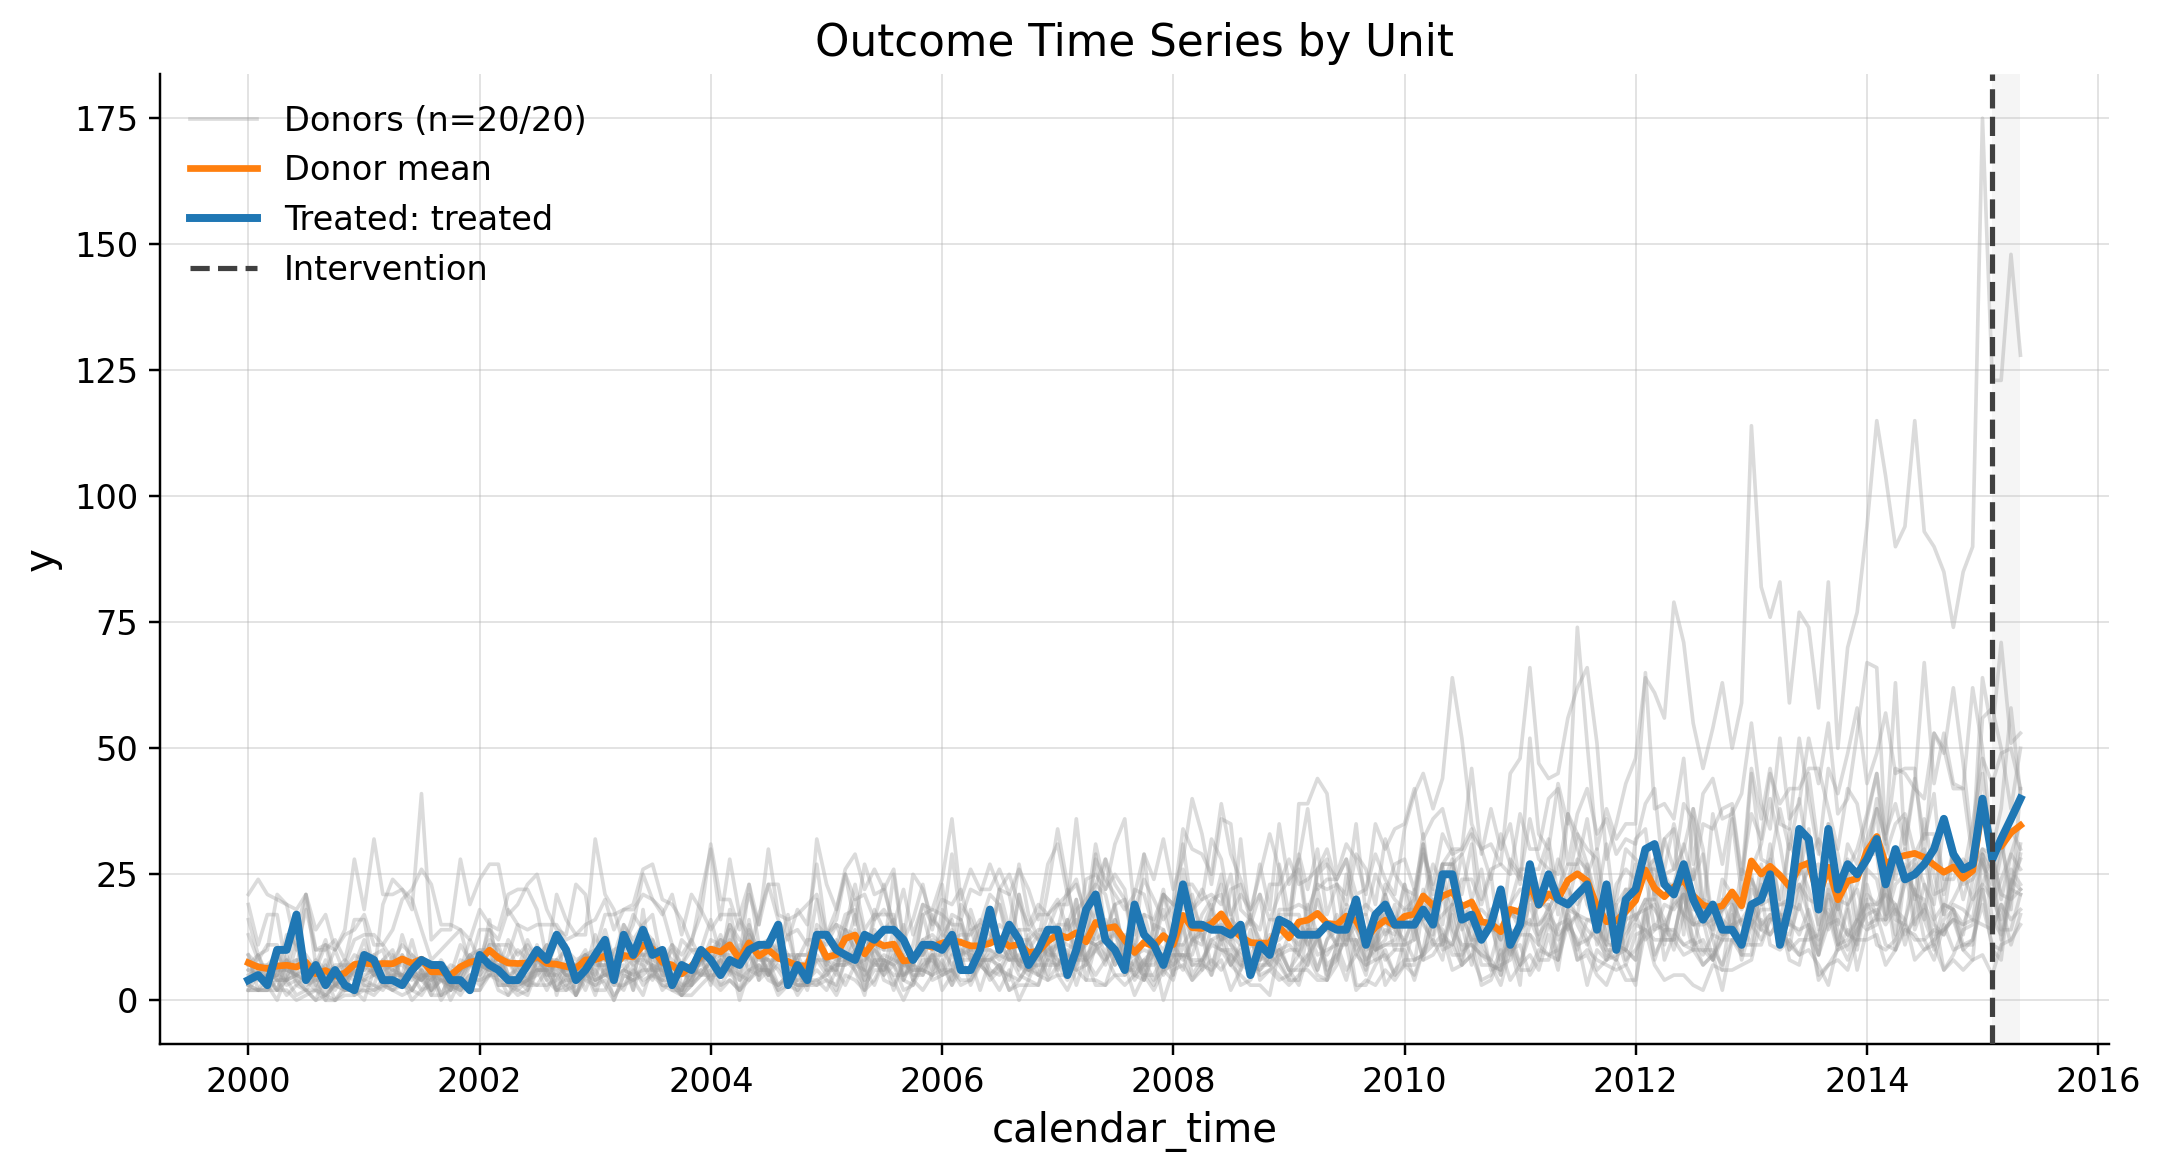

In [7]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot

outcome_panel_plot(paneldata)

# Inference

In [8]:
from causalis.scenarios.synthetic_control import AugmentedSyntheticControl
model = AugmentedSyntheticControl(lambda_aug=200,average_att_n_folds=10).fit(paneldata)
result = model.estimate()

In [9]:
result.summary()

,value
field,
estimand,average_post_effect
model,AugmentedSyntheticControl
inference,average_att_ttest
value,"4.9727 (ci_abs: 0.2503, 9.6951)"
value_relative,"16.9843 (ci_rel: 0.8551, 33.1135)"
alpha,0.0500
p_value,0.0411
is_significant,True
post_outcome_d_mean,34.0000


# Refutation

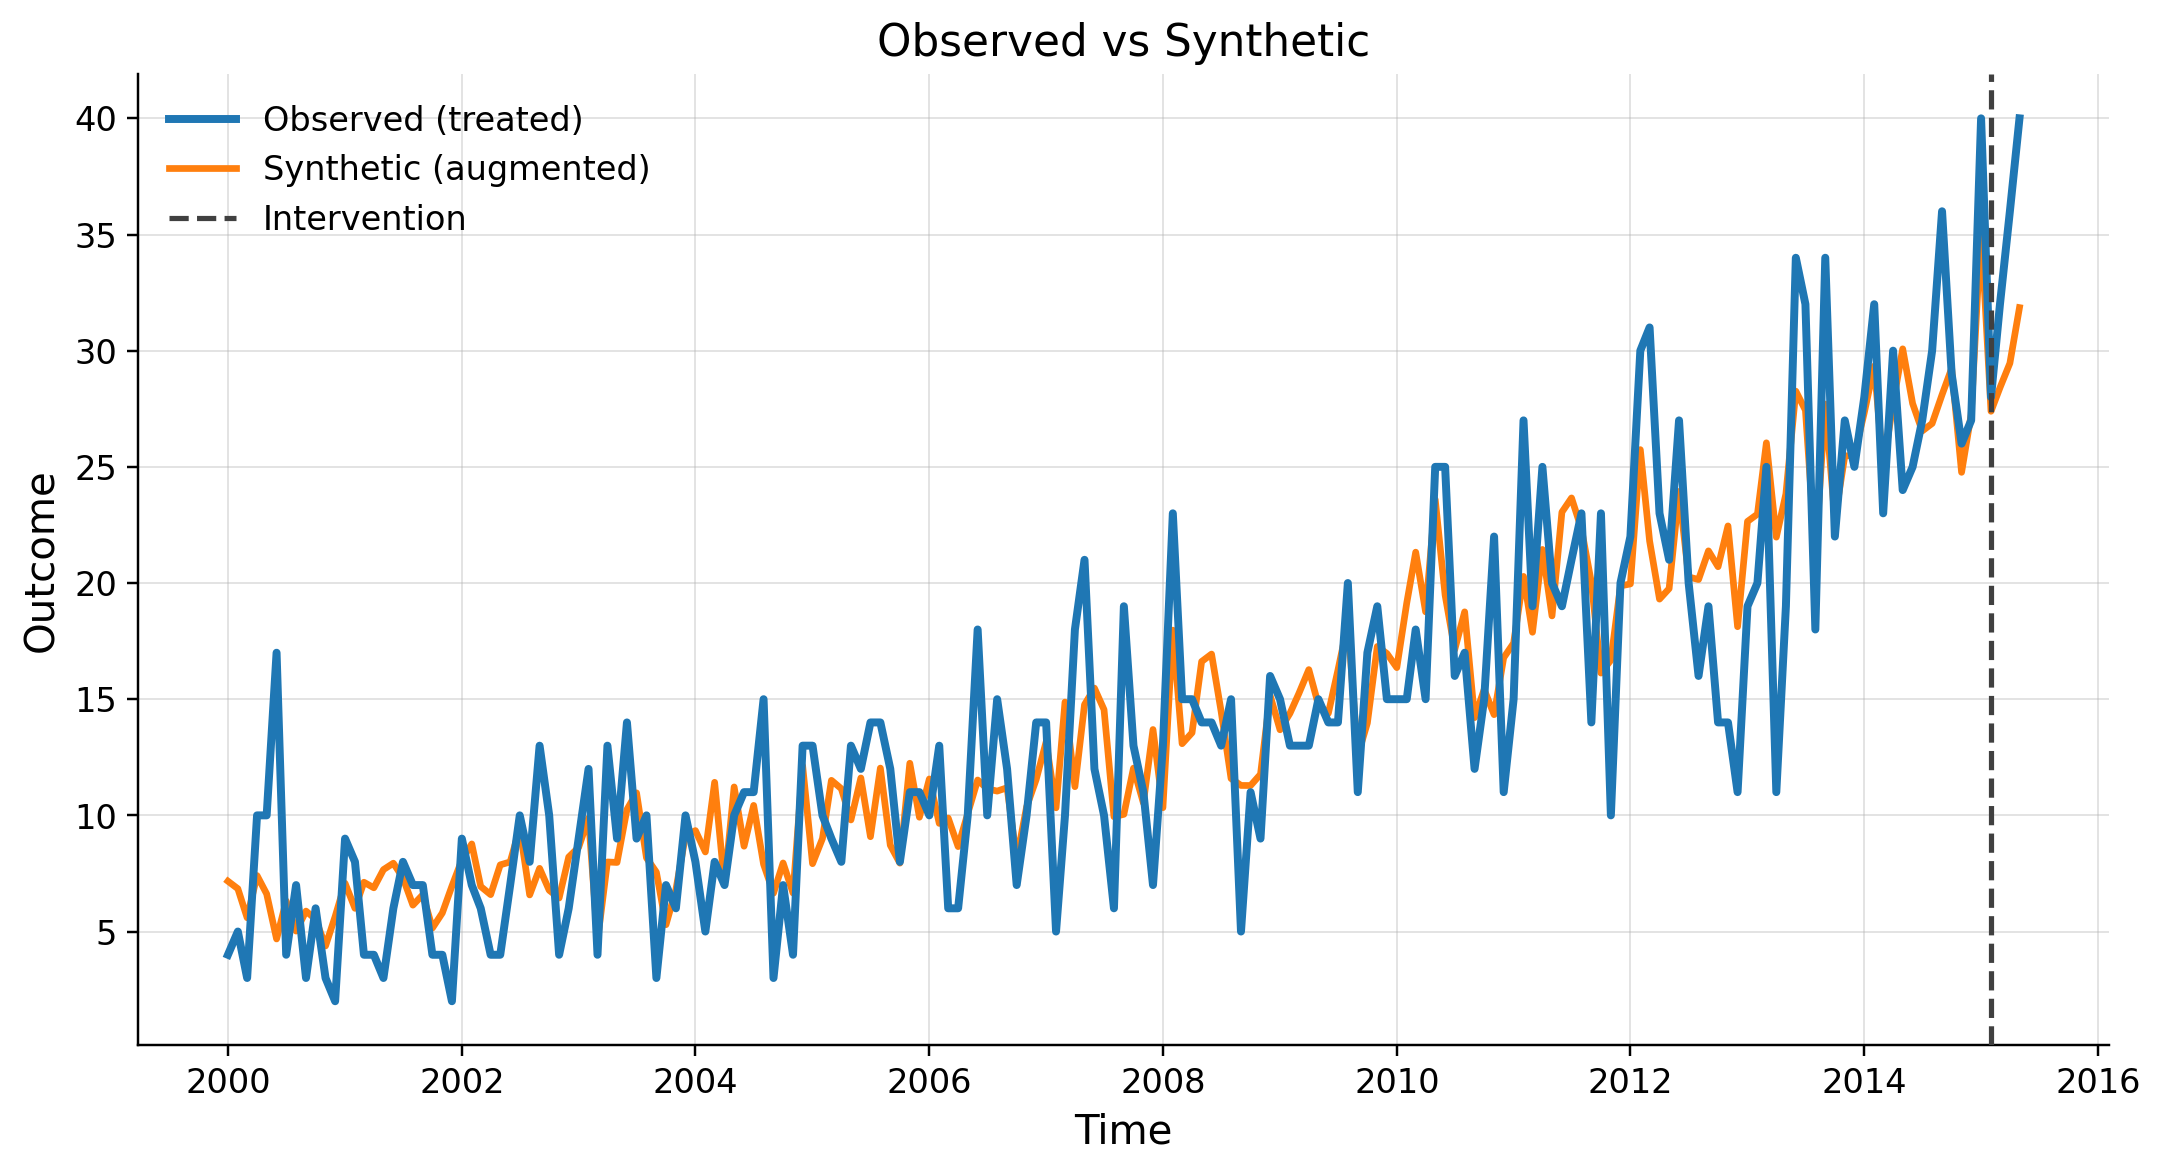

In [10]:
from causalis.scenarios.synthetic_control.refutation import observed_vs_synthetic_plot
observed_vs_synthetic_plot(result)

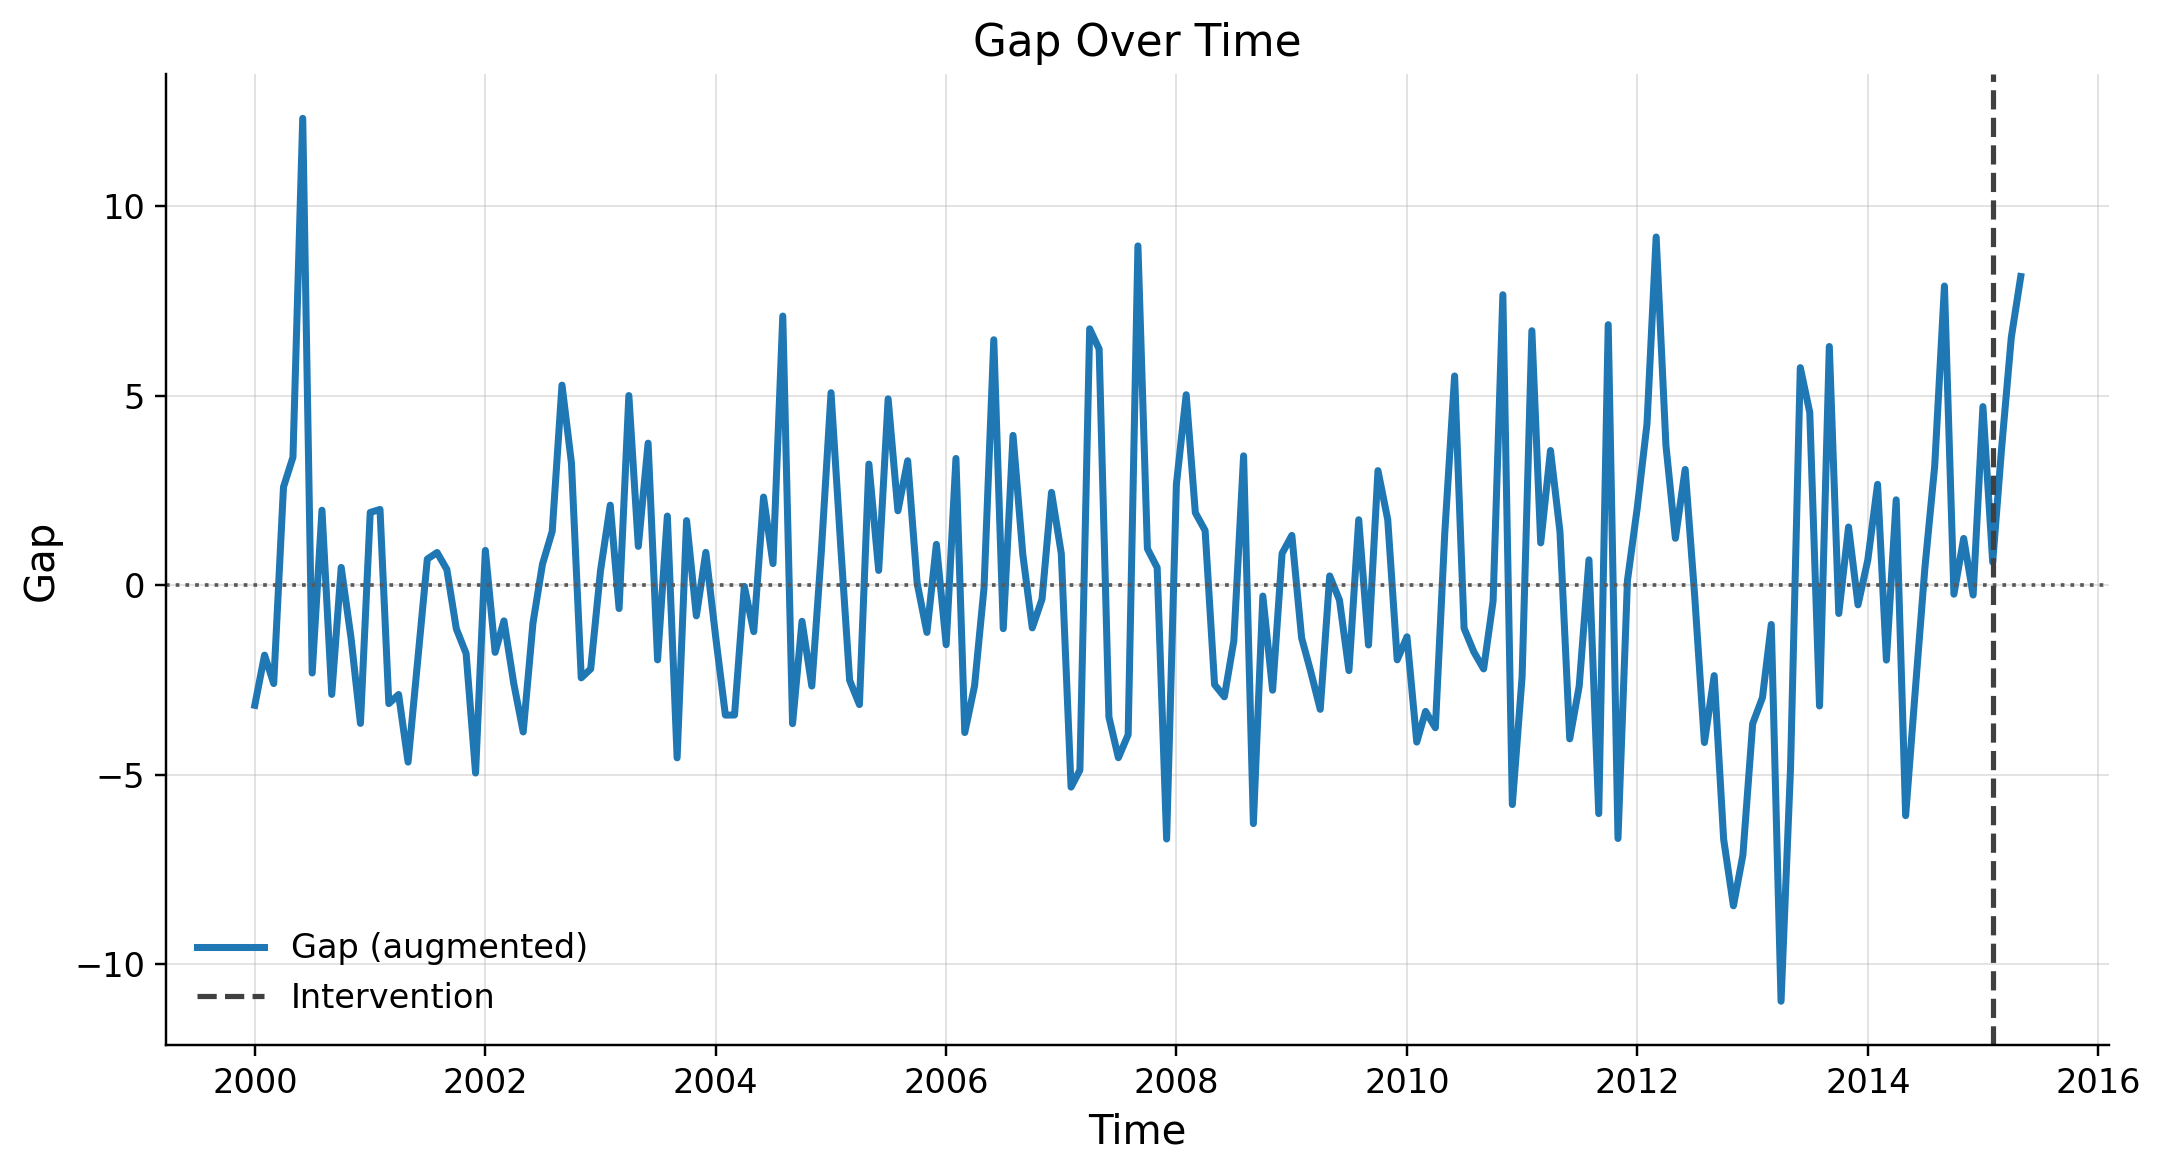

In [11]:
from causalis.scenarios.synthetic_control.refutation import gap_over_time_plot
gap_over_time_plot(result)

## Placebo

In [12]:
## Placebo
from causalis.scenarios.synthetic_control.refutation import (placebo_in_time_table,
                                                             placebo_in_space_table)

In [13]:
placebo_in_time_table(result, paneldata)

,placebo_treatment_start,n_pre_before_placebo,n_post_after_placebo,average_att_placebo,ci_lower,ci_upper,p_value,rejects_zero,pre_fit_metric
0,2000-03,2,4,5.462732,-14.408865,25.334328,0.177510,False,3.957005e-09
1,2000-04,3,4,5.820208,1.568835,10.071582,0.027632,True,1.342351e-09
2,2000-05,4,4,6.443555,-0.217886,13.104995,0.053169,False,1.285495e-02
3,2000-06,5,4,4.912309,-1.310838,11.135455,0.076833,False,9.762317e-03
4,2000-07,6,4,-3.505020,-14.728100,7.718059,0.311187,False,6.010438e-02
...,...,...,...,...,...,...,...,...,...
171,2014-06,173,4,3.033284,-15.201103,21.267671,0.548432,False,3.604817e+00
172,2014-07,174,4,3.855998,-14.376369,22.088365,0.458889,False,3.596280e+00
173,2014-08,175,4,4.315601,-13.943856,22.575058,0.416190,False,3.586448e+00
174,2014-09,176,4,3.386534,-15.538700,22.311768,0.521847,False,3.584910e+00


We pretend treatment has happened earlier.
- placebo_treatment_start - where treatment starts
- n_pre_before_placebo - how many periods were fitted before the treatment
- n_post_after_placebo - how many periods were fitted after the treatment
- average_att_placebo - average_post_effect
- rejects_zero - p_value < alpha

So weak robustness when we have many rows have rejects_zero = false and average_att_placebo is small

In [14]:
placebo_in_space_table(result, paneldata)

,unit_id,pre_rmse,post_rmse,post_pre_rmspe_ratio,average_post_gap,max_abs_post_gap,rank_post_pre_rmspe_ratio,is_actual_treated
0,donor_2,9.908261,42.582403,4.297667,35.069571,71.993440,1,False
1,donor_18,4.160427,13.911060,3.343661,-9.715085,26.366275,2,False
2,donor_11,5.227018,17.008344,3.253929,-7.814759,22.368382,3,False
3,donor_15,7.267022,19.260087,2.650341,-11.741052,36.900028,4,False
4,donor_1,3.161121,7.777379,2.460323,-2.925918,12.693281,5,False
5,donor_14,5.041892,12.241623,2.427982,0.209326,16.893802,6,False
6,donor_7,2.922371,6.708425,2.295542,-0.124026,9.677678,7,False
7,donor_12,2.638915,5.973629,2.263668,3.032937,10.284256,8,False
8,donor_4,3.281984,6.259385,1.907195,1.824818,8.201755,9,False
9,donor_8,3.234938,5.850849,1.808643,-4.736757,9.629960,10,False


How to read columns:

- unit_id: unit used as treated in that placebo run.
- pre_rmse: pre-treatment fit error (lower is better).
- post_rmse: post-treatment fit error.
- post_pre_rmspe_ratio: post_rmse / pre_rmse (main Abadie-style statistic).
- average_post_gap: mean post-treatment gap (observed - synthetic).
- max_abs_post_gap: largest absolute post gap.
- rank_post_pre_rmspe_ratio: rank of ratio, descending (1 = largest ratio).
- is_actual_treated: True for your real treated unit.

Interpretation:
You want the real treated unit (is_actual_treated=True) to have one of the largest post_pre_rmspe_ratio values (ideally rank near 1).
If many placebo units have similar/larger ratios, treatment effect is less convincing.
Also check pre_rmse: if pre-fit is poor for some placebos, their high ratios are less informative.

## Sensitivity

In [15]:
from causalis.scenarios.synthetic_control.refutation import leave_one_donor_out_sensitivity
leave_one_donor_out_sensitivity(result, paneldata)

,dropped_donor,average_att_reestimated,delta_vs_full_model,pre_rmse_reestimated,max_weight_after_refit,effective_n_donors_after_refit
0,donor_1,4.058002,-0.914725,3.698383,0.161013,8.102712
1,donor_10,4.434911,-0.537816,3.639324,0.219260,5.749925
2,donor_11,3.689260,-1.283467,3.688131,0.251006,5.031053
3,donor_12,4.998016,0.025289,3.655190,0.223262,6.959361
4,donor_13,4.487509,-0.485218,3.631670,0.220332,5.983026
5,donor_14,4.617818,-0.354909,3.697599,0.213398,5.489285
6,donor_15,3.880155,-1.092572,3.657946,0.206193,6.328750
7,donor_16,4.561821,-0.410907,3.631450,0.222833,5.832072
8,donor_17,4.260393,-0.712334,3.636798,0.218268,6.296147
9,donor_18,4.148347,-0.824380,3.632912,0.221292,5.896571


- dropped_donor: donor unit removed in that refit.
- average_att_reestimated: ATT after removing that donor.
- delta_vs_full_model: reestimated_ATT - original_full_model_ATT.
Near 0  estimate is stable to that donor.
Large |deltal  that donor is influential.
- pre_rmse_reestimated: pre-treatment fit error after refit. Higher than baseline  worse pre-fit when donor is removed.
- max_weight_afterrefit: largest donor weight in refit.Very high (close to 1)  dependence on one donor.
-  effective_n_donors_after_refit: effective donor count (1 / sum (w^2)). Lower  concentration on fewer donors.

## Model

In [16]:
from causalis.scenarios.synthetic_control.refutation import run_scm_diagnostics

run_scm_diagnostics(result, paneldata)

{'metrics': {'n_donors': 20,
  'n_pre': 181,
  'n_post': 4,
  'pre_rmse_sc': None,
  'pre_rmse_aug': 3.63162621137165,
  'pre_rmse_augmented': 3.63162621137165,
  'pre_mae_augmented': 2.865683953423894,
  'max_abs_pre_gap': 12.319490234592525,
  'max_abs_pre_gap_augmented': 12.319490234592525,
  'mean_signed_pre_gap': -0.093703057672044,
  'mean_signed_pre_gap_augmented': -0.093703057672044,
  'att_sc': None,
  'att_aug': 4.972727350333998,
  'max_weight_sc': 0.1878646195458257,
  'max_abs_weight_aug': 0.21641008257012256,
  'max_abs_weight_augmented': 0.21641008257012256,
  'l1_norm_weight_aug': 1.36881478737466,
  'l1_norm_weights_augmented': 1.36881478737466,
  'sum_weights_augmented': 1.0,
  'effective_n_donors': None,
  'effective_n_donors_sc': None,
  'herfindahl_weights': None,
  'herfindahl_weights_sc': None,
  'effective_n_donors_abs_augmented': 11.74898939775322,
  'herfindahl_abs_augmented': 0.0851137034978712,
  'negative_weight_share': 0.13472048621056845,
  'n_negative_we